# Creación aleatoria de datos

In [1]:
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

# Medidas de tendencia central

In [2]:
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


# Medidas de posición

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


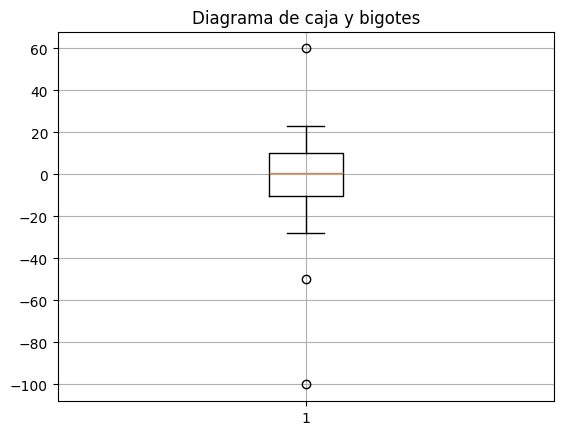

In [10]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

# Medidas de dispersión

In [4]:
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


# Medidas de distribución

In [5]:
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [6]:
# Cargar el set de datos de Iris (ya está en tu celda, pero asegúrate de ejecutarlo)
from sklearn import datasets
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
# La longitud del pétalo es la tercera columna (índice 2)
petal_length = X[:, 2]
asimetria_petal = stats.skew(petal_length)
print(f'Asimetría de la longitud del pétalo: {np.round(asimetria_petal, 4)}')

if asimetria_petal > 0:
    print('Asimetría positiva (cola a la derecha)')
elif asimetria_petal < 0:
    print('Asimetría negativa (cola a la izquierda)')
else:
    print('Distribución simétrica')

print("-" * 30)

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
# El ancho del sépalo es la segunda columna (índice 1)
sepal_width = X[:, 1]
curtosis_sepal = stats.kurtosis(sepal_width, fisher=True)
print(f'Curtosis del ancho del sépalo: {np.round(curtosis_sepal, 4)}')

if curtosis_sepal > 0:
    print('Distribución Leptocúrtica')
elif curtosis_sepal < 0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría de la longitud del pétalo: -0.2721
Asimetría negativa (cola a la izquierda)
------------------------------
Curtosis del ancho del sépalo: 0.181
Distribución Leptocúrtica


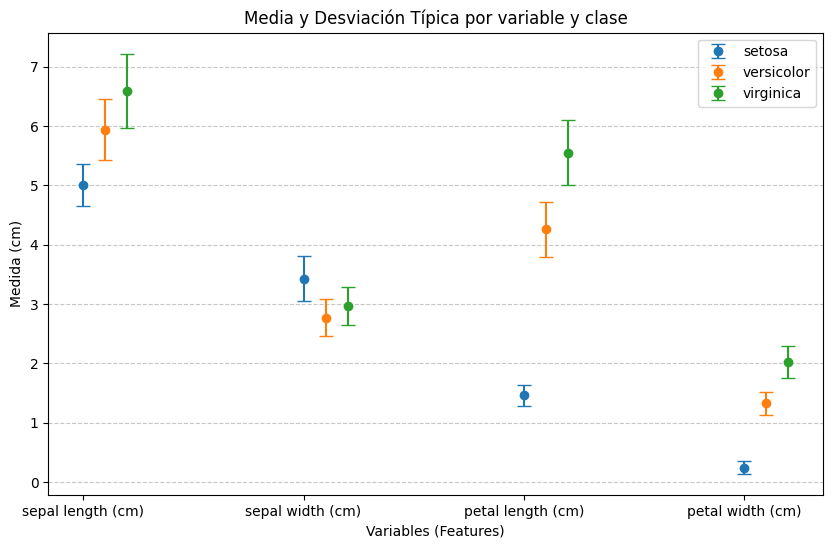

In [7]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
plt.figure(figsize=(10, 6))

feature_names = iris.feature_names
target_names = iris.target_names

# Iteramos por cada una de las 3 clases de flores
for i in range(len(target_names)):
    # Filtramos los datos que pertenecen a la clase i
    datos_clase = X[y == i]
    
    # Calculamos la media y desviación típica de las 4 variables para esa clase
    medias = np.mean(datos_clase, axis=0)
    desviaciones = np.std(datos_clase, axis=0)
    
    # Dibujamos las barras de error
    # Sumamos un pequeño desplazamiento (i*0.1) al eje x para que no se solapen
    plt.errorbar(np.arange(len(feature_names)) + (i*0.1), medias, yerr=desviaciones, 
                 fmt='o', capsize=5, label=target_names[i])

# Configuración del gráfico
plt.xticks(np.arange(len(feature_names)), feature_names)
plt.title("Media y Desviación Típica por variable y clase")
plt.xlabel("Variables (Features)")
plt.ylabel("Medida (cm)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El resultado debería ser algo como esto:
<img src="images/errorbar.png">

# GitHub 

- [https://github.com/ndadri/Cuaderno_python2](https://github.com/ndadri/Cuaderno_python2) 